In [1]:
# Deep Learning Time Series Models
# Models: LSTM, GRU, Multivariate LSTM (with features)
# Dataset: Store Item Demand Forecasting (Kaggle)
# Framework: TensorFlow / Keras
# Author: Nabin Katwal | Retail Demand Forecasting Portfolio Project
#
# NOTE: These models train per store-item series or on all data with features.
#       We show both approaches.

In [2]:
# !pip install tensorflow scikit-learn pandas numpy matplotlib

In [3]:
# Importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import os
import json
warnings.filterwarnings("ignore")
 
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    LSTM, GRU, Dense, Dropout, Input,
    BatchNormalization, Bidirectional
)
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
)
from tensorflow.keras.optimizers import Adam
 
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
 
tf.random.set_seed(42)
np.random.seed(42)
 
plt.rcParams["figure.figsize"] = (14, 5)
os.makedirs("saved_models", exist_ok=True)
 
print(" Libraries imported")
print(f"TensorFlow version: {tf.__version__}")


 Libraries imported
TensorFlow version: 2.15.0


In [4]:
# Load Data
train = pd.read_csv("train.csv")
train["date"] = pd.to_datetime(train["date"])
train = train.sort_values(["store", "item", "date"]).reset_index(drop=True)
 
print("Train shape:", train.shape)
print("Date range:", train["date"].min(), "→", train["date"].max())

Train shape: (913000, 4)
Date range: 2013-01-01 00:00:00 → 2017-12-31 00:00:00


In [6]:
# Extract Single Series (Store 1, Item 1 for LSTM & GRU)
series = (
    train[(train["store"] == 1) & (train["item"] == 1)]
    .set_index("date")["sales"]
    .asfreq("D")
    .sort_index()
    .values.astype(float)
)
 
print(f"Series length: {len(series)}")
print(f"Min: {series.min()}, Max: {series.max()}, Mean: {series.mean():.2f}")

Series length: 1826
Min: 4.0, Max: 50.0, Mean: 19.97


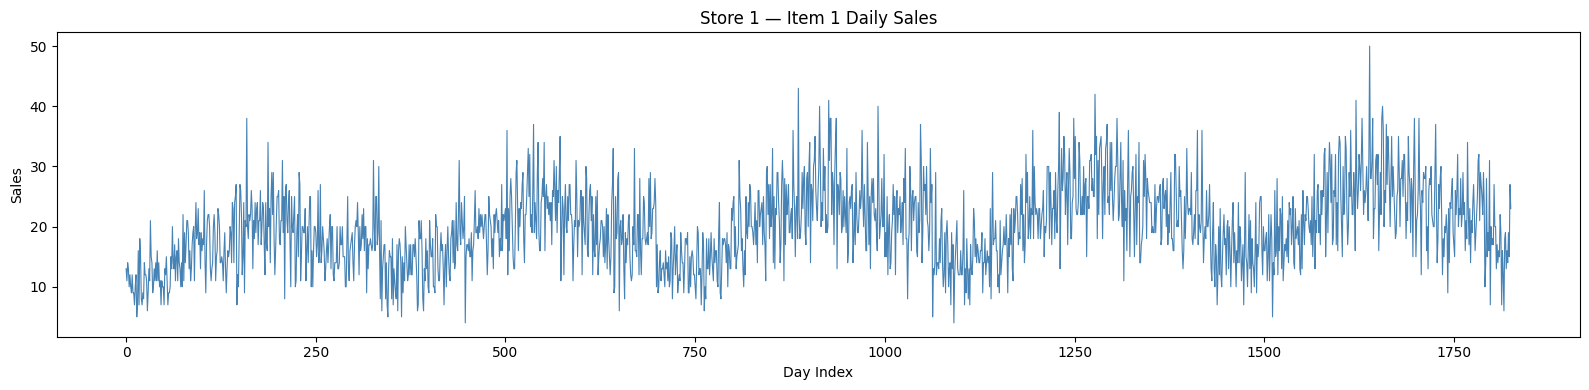

In [7]:
# Plot
plt.figure(figsize=(16, 4))
plt.plot(series, color="steelblue", linewidth=0.8)
plt.title("Store 1 — Item 1 Daily Sales")
plt.xlabel("Day Index"); plt.ylabel("Sales")
plt.tight_layout()
plt.show()

In [8]:
# Scale Data
scaler = MinMaxScaler(feature_range=(0, 1))
series_scaled = scaler.fit_transform(series.reshape(-1, 1)).flatten()
 
print(f"Scaled series — Min: {series_scaled.min():.3f}, Max: {series_scaled.max():.3f}")
 
# Save scaler
import joblib
joblib.dump(scaler, "saved_models/lstm_scaler.pkl")

Scaled series — Min: 0.000, Max: 1.000


['saved_models/lstm_scaler.pkl']

In [9]:
# Create Sequences for LSTM / GRU
def create_sequences(data, lookback=60):
    """
    Create (X, y) pairs from a 1D time series.
    X: window of `lookback` past values
    y: next value to predict
    """
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i - lookback: i])
        y.append(data[i])
    return np.array(X), np.array(y)
 
LOOKBACK = 60   # use past 60 days to predict next day
 
X_seq, y_seq = create_sequences(series_scaled, lookback=LOOKBACK)
 
# Reshape X to (samples, timesteps, features) — required by LSTM/GRU
X_seq = X_seq.reshape(X_seq.shape[0], X_seq.shape[1], 1)
 
print(f"X_seq shape: {X_seq.shape}")   # (samples, 60, 1)
print(f"y_seq shape: {y_seq.shape}")   # (samples,)

X_seq shape: (1766, 60, 1)
y_seq shape: (1766,)


In [11]:
# Time-Based Train / Validation Split
# Last 90 days as validation
val_size = 90
split_idx = len(X_seq) - val_size
 
X_train, X_val = X_seq[:split_idx], X_seq[split_idx:]
y_train, y_val = y_seq[:split_idx], y_seq[split_idx:]
 
print(f"X_train: {X_train.shape}, X_val: {X_val.shape}")

X_train: (1676, 60, 1), X_val: (90, 60, 1)


In [12]:
# Helper: Evaluate & Plot
def evaluate_dl(model_name, y_true_scaled, y_pred_scaled, scaler):
    """Inverse transform predictions and compute metrics."""
    y_true = scaler.inverse_transform(y_true_scaled.reshape(-1, 1)).flatten()
    y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    y_pred = np.clip(y_pred, 0, None)
 
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    smape = np.mean(
        200 * np.abs(y_pred - y_true) / (np.abs(y_pred) + np.abs(y_true) + 1e-8)
    )
 
    print(f"\n{'='*40}")
    print(f"Model : {model_name}")
    print(f"MAE   : {mae:.4f}")
    print(f"RMSE  : {rmse:.4f}")
    print(f"SMAPE : {smape:.2f}%")
    print(f"{'='*40}")
 
    # Plot
    plt.figure(figsize=(14, 4))
    plt.plot(y_true, label="Actual", color="steelblue")
    plt.plot(y_pred, label="Predicted", color="coral", alpha=0.85)
    plt.title(f"Actual vs Predicted — {model_name} (Validation Set)")
    plt.legend()
    plt.tight_layout()
    plt.show()
 
    return {"Model": model_name, "MAE": round(mae, 4),
            "RMSE": round(rmse, 4), "SMAPE": round(smape, 2)}, y_true, y_pred

In [13]:
def plot_training_history(history, model_name):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history["loss"],     label="Train Loss")
    plt.plot(history.history["val_loss"], label="Val Loss")
    plt.title(f"{model_name} — Loss Curve")
    plt.xlabel("Epoch"); plt.ylabel("MSE Loss")
    plt.legend()
 
    plt.subplot(1, 2, 2)
    if "mae" in history.history:
        plt.plot(history.history["mae"],     label="Train MAE")
        plt.plot(history.history["val_mae"], label="Val MAE")
        plt.title(f"{model_name} — MAE Curve")
        plt.xlabel("Epoch"); plt.ylabel("MAE")
        plt.legend()
 
    plt.tight_layout()
    plt.show()
 
 
results_dl = []

In [14]:
# Callbacks (shared by all DL models)
def get_callbacks(model_name):
    return [
        EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True,
                      verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=7,
                         min_lr=1e-6, verbose=1),
        ModelCheckpoint(
            filepath=f"saved_models/{model_name.lower().replace(' ', '_')}_best.keras",
            monitor="val_loss", save_best_only=True, verbose=0
        )
    ]

Building LSTM model...

Model: "LSTM_Univariate"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 60, 64)            16896     
                                                                 
 dropout (Dropout)           (None, 60, 64)            0         
                                                                 
 batch_normalization (Batch  (None, 60, 64)            256       
 Normalization)                                                  
                                                                 
 lstm_1 (LSTM)               (None, 32)                12416     
                                                                 
 dropout_1 (Dropout)         (None, 32)                0         
                                                                 
 batch_normalization_1 (Bat  (None, 32)                128       
 chNormalization)          

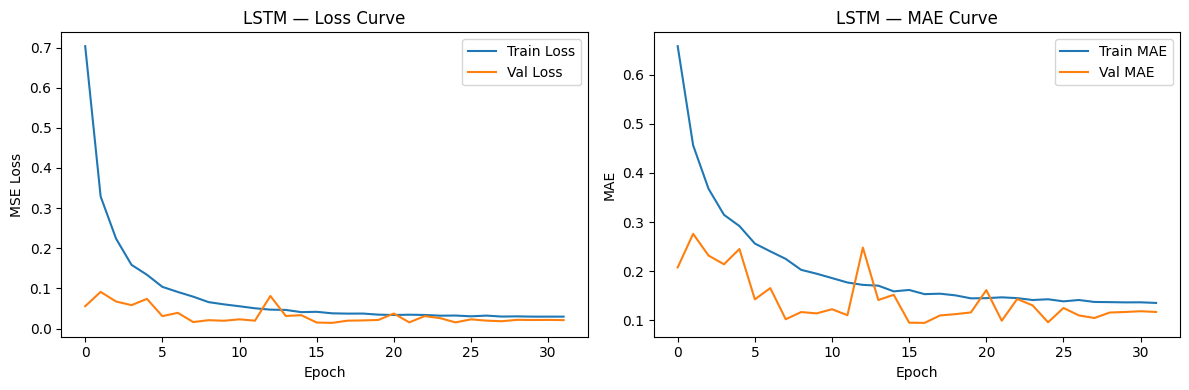

3/3 [==============================] - 1s 16ms/step

Model : LSTM (Univariate)
MAE   : 4.3549
RMSE  : 5.4533
SMAPE : 22.45%


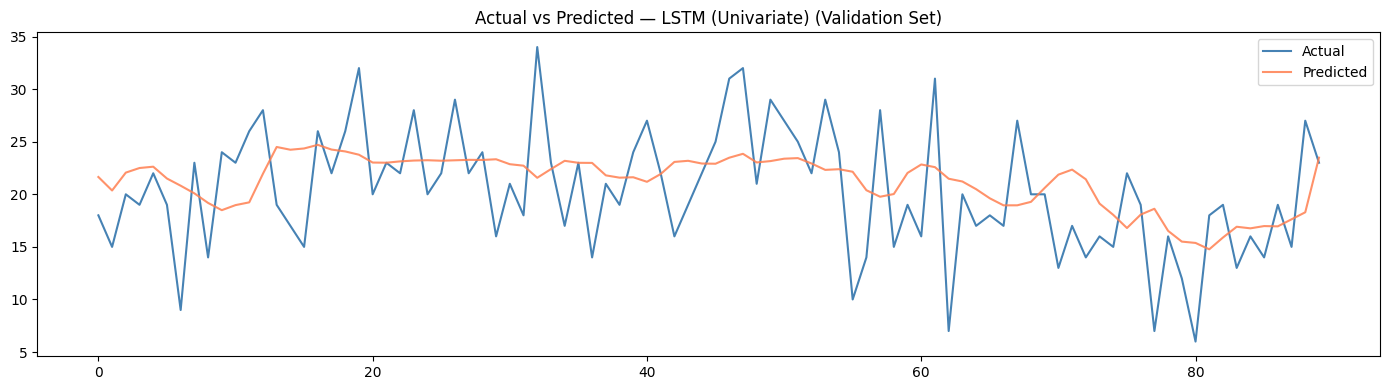

LSTM model saved


In [16]:
# MODEL 1: LSTM (Univariate)

print("Building LSTM model...")
 
lstm_model = Sequential([
    # Layer 1: LSTM returning full sequences
    LSTM(64, return_sequences=True, input_shape=(LOOKBACK, 1)),
    Dropout(0.2),
    BatchNormalization(),
 
    # Layer 2: LSTM returning last step only
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    BatchNormalization(),
 
    # Output layer
    Dense(16, activation="relu"),
    Dense(1)
], name="LSTM_Univariate")
 
lstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)
 
lstm_model.summary()
 
# Train
lstm_history = lstm_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=get_callbacks("lstm"),
    shuffle=False,   # do NOT shuffle time series data
    verbose=1
)
 
plot_training_history(lstm_history, "LSTM")
 
# Predict
lstm_preds = lstm_model.predict(X_val).flatten()
metrics, _, _ = evaluate_dl("LSTM (Univariate)", y_val, lstm_preds, scaler)
results_dl.append(metrics)
 
# Save full model
lstm_model.save("saved_models/lstm_model.keras")
print("LSTM model saved")

Building GRU model...
Model: "GRU_Univariate"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru (GRU)                   (None, 60, 64)            12864     
                                                                 
 dropout_2 (Dropout)         (None, 60, 64)            0         
                                                                 
 batch_normalization_2 (Bat  (None, 60, 64)            256       
 chNormalization)                                                
                                                                 
 gru_1 (GRU)                 (None, 32)                9408      
                                                                 
 dropout_3 (Dropout)         (None, 32)                0         
                                                                 
 batch_normalization_3 (Bat  (None, 32)                128       
 chNormalization)             

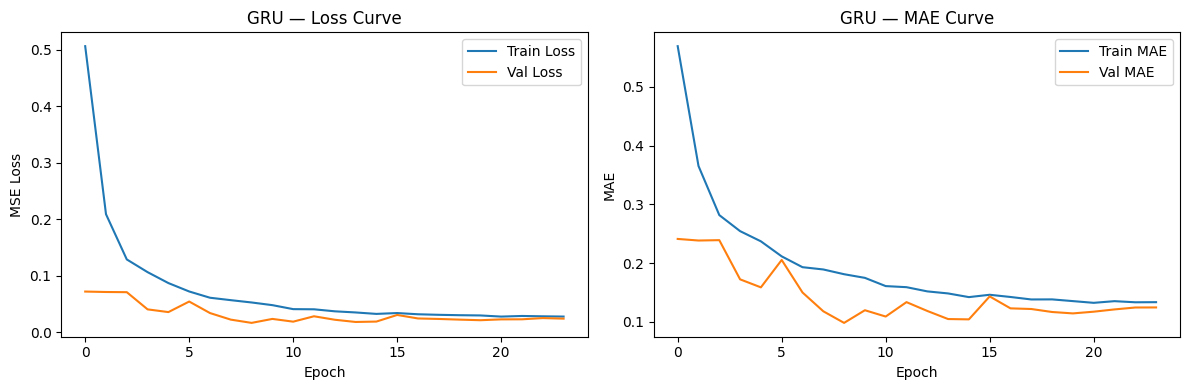

3/3 [==============================] - 7s 117ms/step

Model : GRU (Univariate)
MAE   : 4.5169
RMSE  : 5.8901
SMAPE : 23.29%


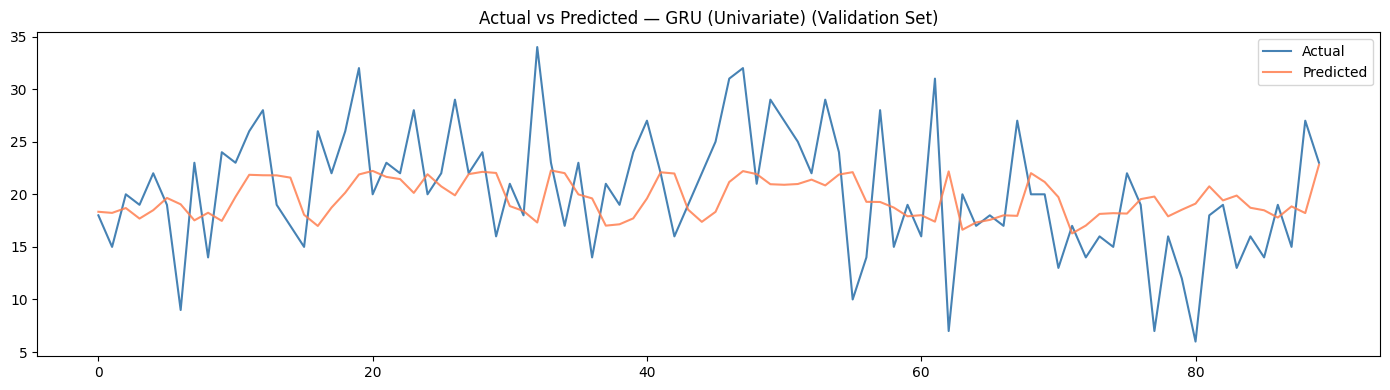

GRU model saved


In [17]:
# MODEL 2: GRU (Univariate)
print("Building GRU model...")
 
gru_model = Sequential([
    GRU(64, return_sequences=True, input_shape=(LOOKBACK, 1)),
    Dropout(0.2),
    BatchNormalization(),
 
    GRU(32, return_sequences=False),
    Dropout(0.2),
    BatchNormalization(),
 
    Dense(16, activation="relu"),
    Dense(1)
], name="GRU_Univariate")
 
gru_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)
 
gru_model.summary()
 
# Train
gru_history = gru_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=get_callbacks("gru"),
    shuffle=False,
    verbose=1
)
 
plot_training_history(gru_history, "GRU")
 
# Predict
gru_preds = gru_model.predict(X_val).flatten()
metrics, _, _ = evaluate_dl("GRU (Univariate)", y_val, gru_preds, scaler)
results_dl.append(metrics)
 
gru_model.save("saved_models/gru_model.keras")
print("GRU model saved")

Building Bidirectional LSTM model...
Model: "BiLSTM_Univariate"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bidirectional (Bidirection  (None, 60, 128)           33792     
 al)                                                             
                                                                 
 dropout_4 (Dropout)         (None, 60, 128)           0         
                                                                 
 batch_normalization_4 (Bat  (None, 60, 128)           512       
 chNormalization)                                                
                                                                 
 bidirectional_1 (Bidirecti  (None, 64)                41216     
 onal)                                                           
                                                                 
 dropout_5 (Dropout)         (None, 64)                0         
            

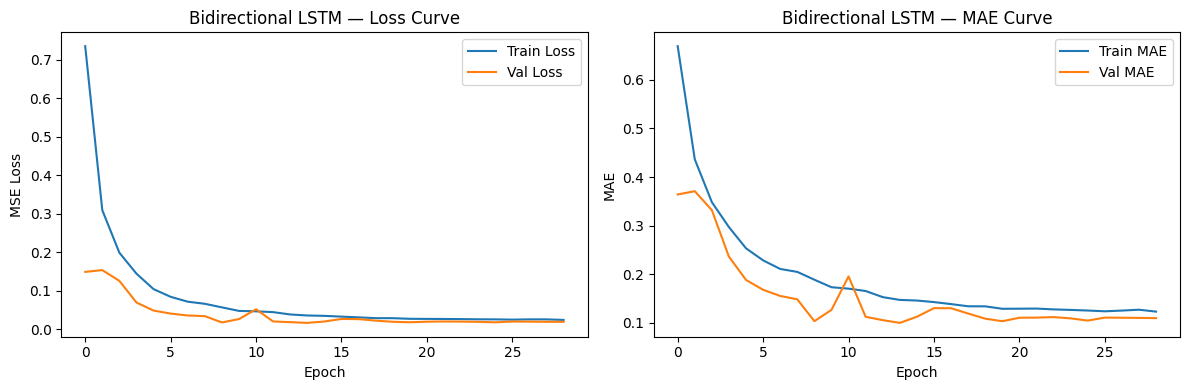

3/3 [==============================] - 2s 17ms/step

Model : BiLSTM (Univariate)
MAE   : 4.6036
RMSE  : 5.8163
SMAPE : 23.55%


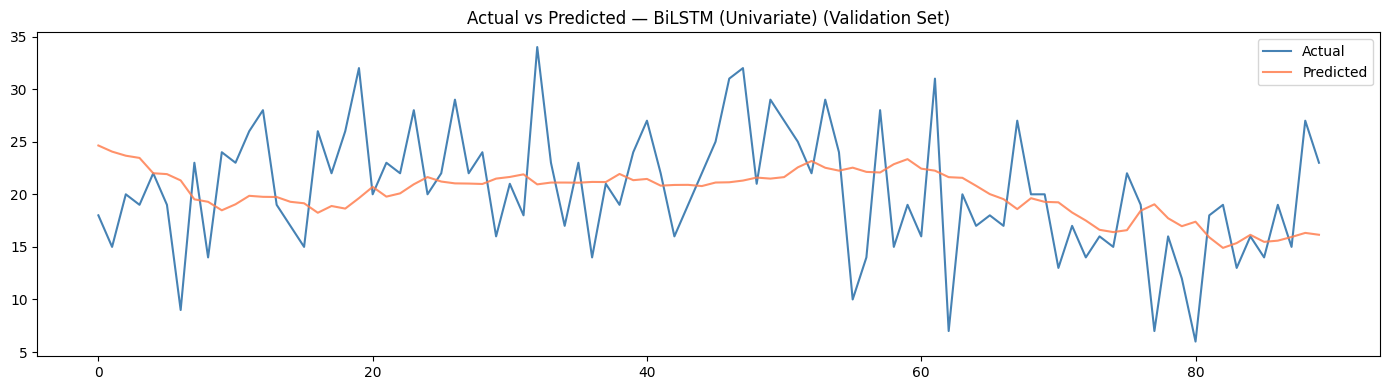

BiLSTM model saved


In [18]:
# MODEL 3: Bidirectional LSTM
print("Building Bidirectional LSTM model...")
 
bilstm_model = Sequential([
    Bidirectional(LSTM(64, return_sequences=True), input_shape=(LOOKBACK, 1)),
    Dropout(0.2),
    BatchNormalization(),
 
    Bidirectional(LSTM(32, return_sequences=False)),
    Dropout(0.2),
    BatchNormalization(),
 
    Dense(16, activation="relu"),
    Dense(1)
], name="BiLSTM_Univariate")
 
bilstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)
 
bilstm_model.summary()
 
bilstm_history = bilstm_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=get_callbacks("bilstm"),
    shuffle=False,
    verbose=1
)
 
plot_training_history(bilstm_history, "Bidirectional LSTM")
 
bilstm_preds = bilstm_model.predict(X_val).flatten()
metrics, _, _ = evaluate_dl("BiLSTM (Univariate)", y_val, bilstm_preds, scaler)
results_dl.append(metrics)
 
bilstm_model.save("saved_models/bilstm_model.keras")
print("BiLSTM model saved")

Multivariate DataFrame shape: (1798, 16)
Features used: ['dayofweek', 'month', 'is_weekend', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'doy_sin', 'doy_cos', 'lag_7', 'lag_14', 'lag_28', 'roll_mean_7', 'roll_mean_14', 'roll_std_7']
X_mv shape: (1768, 30, 15), y_mv shape: (1768,)
Building Multivariate LSTM model...
Model: "Multivariate_LSTM"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_4 (LSTM)               (None, 30, 128)           73728     
                                                                 
 dropout_6 (Dropout)         (None, 30, 128)           0         
                                                                 
 batch_normalization_6 (Bat  (None, 30, 128)           512       
 chNormalization)                                                
                                                                 
 lstm_5 (LSTM)               (None, 30, 64)            494

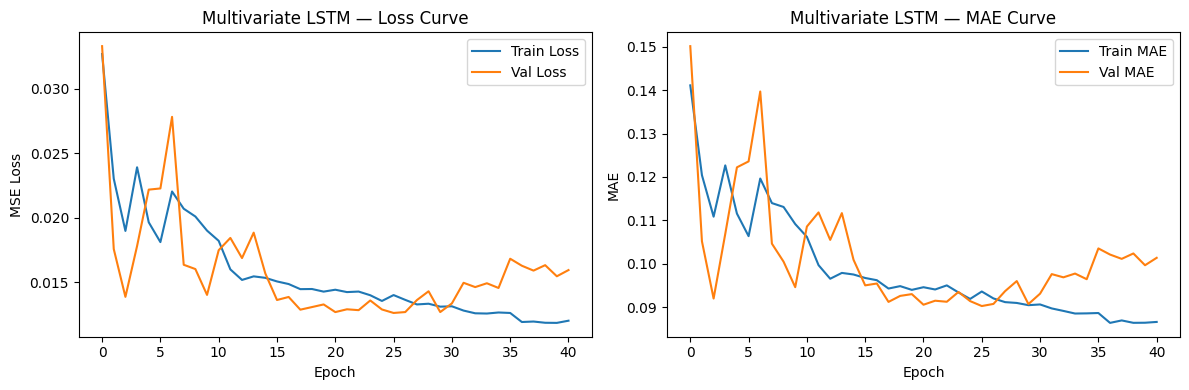

3/3 [==============================] - 2s 23ms/step

Model : Multivariate LSTM
MAE   : 4.1515
RMSE  : 5.1713
SMAPE : 21.52%


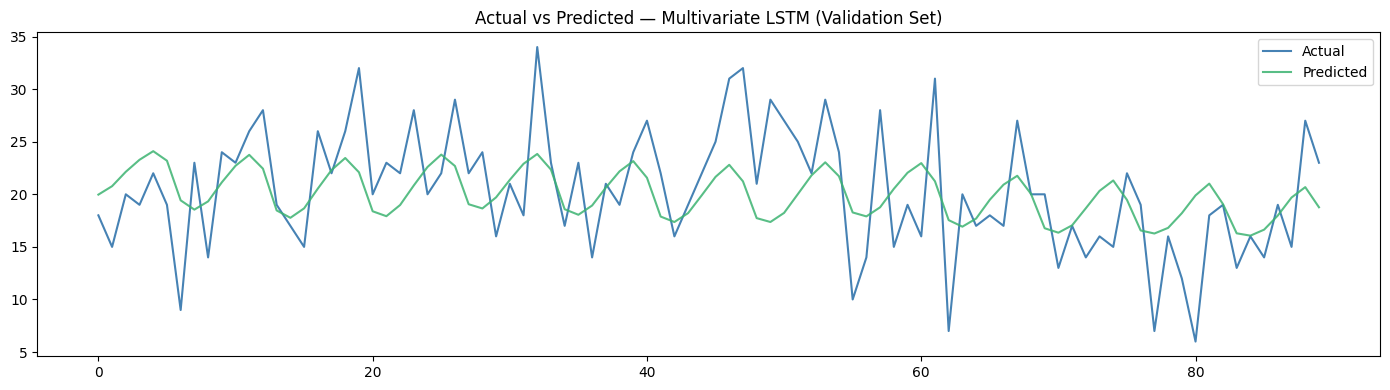

Multivariate LSTM saved


In [19]:
# MODEL 4: Multivariate LSTM (with temporal features)
# Build feature matrix with extra signals
 
def build_multivariate_df(df, store_id, item_id):
    """Build a multivariate DataFrame for one store-item series."""
    ts = df[(df["store"] == store_id) & (df["item"] == item_id)].copy()
    ts = ts.set_index("date").asfreq("D").sort_index()
 
    ts["dayofweek"]  = ts.index.dayofweek
    ts["month"]      = ts.index.month
    ts["dayofyear"]  = ts.index.dayofyear
    ts["is_weekend"] = (ts.index.dayofweek >= 5).astype(int)
 
    # Cyclical encoding
    ts["month_sin"]     = np.sin(2 * np.pi * ts["month"] / 12)
    ts["month_cos"]     = np.cos(2 * np.pi * ts["month"] / 12)
    ts["dow_sin"]       = np.sin(2 * np.pi * ts["dayofweek"] / 7)
    ts["dow_cos"]       = np.cos(2 * np.pi * ts["dayofweek"] / 7)
    ts["doy_sin"]       = np.sin(2 * np.pi * ts["dayofyear"] / 365)
    ts["doy_cos"]       = np.cos(2 * np.pi * ts["dayofyear"] / 365)
 
    # Lag features
    ts["lag_7"]  = ts["sales"].shift(7)
    ts["lag_14"] = ts["sales"].shift(14)
    ts["lag_28"] = ts["sales"].shift(28)
 
    # Rolling features
    ts["roll_mean_7"]  = ts["sales"].shift(1).rolling(7).mean()
    ts["roll_mean_14"] = ts["sales"].shift(1).rolling(14).mean()
    ts["roll_std_7"]   = ts["sales"].shift(1).rolling(7).std()
 
    ts = ts.dropna()
 
    feature_cols = [
        "dayofweek", "month", "is_weekend",
        "month_sin", "month_cos", "dow_sin", "dow_cos", "doy_sin", "doy_cos",
        "lag_7", "lag_14", "lag_28",
        "roll_mean_7", "roll_mean_14", "roll_std_7"
    ]
    target_col = "sales"
 
    return ts[feature_cols + [target_col]], feature_cols
 
mv_df, mv_feature_cols = build_multivariate_df(train, store_id=1, item_id=1)
print(f"Multivariate DataFrame shape: {mv_df.shape}")
print(f"Features used: {mv_feature_cols}")
 
# Scale features and target separately
n_features = len(mv_feature_cols)
 
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
 
X_mv_scaled = scaler_X.fit_transform(mv_df[mv_feature_cols].values)
y_mv_scaled = scaler_y.fit_transform(mv_df[["sales"]].values).flatten()
 
joblib.dump(scaler_X, "saved_models/mv_scaler_X.pkl")
joblib.dump(scaler_y, "saved_models/mv_scaler_y.pkl")
 
# Create sequences (multivariate)
def create_sequences_mv(X, y, lookback=30):
    Xs, ys = [], []
    for i in range(lookback, len(X)):
        Xs.append(X[i - lookback: i, :])   # (lookback, n_features)
        ys.append(y[i])
    return np.array(Xs), np.array(ys)
 
MV_LOOKBACK = 30    # shorter lookback for multivariate (more features = more capacity)
X_mv, y_mv = create_sequences_mv(X_mv_scaled, y_mv_scaled, lookback=MV_LOOKBACK)
print(f"X_mv shape: {X_mv.shape}, y_mv shape: {y_mv.shape}")
 
# Split
val_size_mv = 90
split_mv = len(X_mv) - val_size_mv
X_mv_train, X_mv_val = X_mv[:split_mv], X_mv[split_mv:]
y_mv_train, y_mv_val = y_mv[:split_mv], y_mv[split_mv:]
 
# Build Multivariate LSTM
print("Building Multivariate LSTM model...")
 
mv_lstm = Sequential([
    LSTM(128, return_sequences=True, input_shape=(MV_LOOKBACK, n_features)),
    Dropout(0.2),
    BatchNormalization(),
 
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    BatchNormalization(),
 
    LSTM(32, return_sequences=False),
    Dropout(0.2),
 
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(1)
], name="Multivariate_LSTM")
 
mv_lstm.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)
 
mv_lstm.summary()
 
mv_history = mv_lstm.fit(
    X_mv_train, y_mv_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_mv_val, y_mv_val),
    callbacks=get_callbacks("mv_lstm"),
    shuffle=False,
    verbose=1
)
 
plot_training_history(mv_history, "Multivariate LSTM")
 
# Evaluate — inverse transform with scaler_y
mv_preds_scaled = mv_lstm.predict(X_mv_val).flatten()
mv_preds = scaler_y.inverse_transform(mv_preds_scaled.reshape(-1, 1)).flatten()
mv_true  = scaler_y.inverse_transform(y_mv_val.reshape(-1, 1)).flatten()
mv_preds = np.clip(mv_preds, 0, None)
 
mv_mae  = mean_absolute_error(mv_true, mv_preds)
mv_rmse = np.sqrt(mean_squared_error(mv_true, mv_preds))
mv_smape = np.mean(200 * np.abs(mv_preds - mv_true) / (np.abs(mv_preds) + np.abs(mv_true) + 1e-8))
 
print(f"\n{'='*40}")
print(f"Model : Multivariate LSTM")
print(f"MAE   : {mv_mae:.4f}")
print(f"RMSE  : {mv_rmse:.4f}")
print(f"SMAPE : {mv_smape:.2f}%")
print(f"{'='*40}")
 
results_dl.append({
    "Model": "Multivariate LSTM",
    "MAE": round(mv_mae, 4),
    "RMSE": round(mv_rmse, 4),
    "SMAPE": round(mv_smape, 2)
})
 
plt.figure(figsize=(14, 4))
plt.plot(mv_true, label="Actual", color="steelblue")
plt.plot(mv_preds, label="Predicted", color="mediumseagreen", alpha=0.85)
plt.title("Actual vs Predicted — Multivariate LSTM (Validation Set)")
plt.legend()
plt.tight_layout()
plt.show()
 
mv_lstm.save("saved_models/mv_lstm_model.keras")
 
# Save metadata needed for inference
mv_meta = {"lookback": MV_LOOKBACK, "n_features": n_features, "features": mv_feature_cols}
with open("saved_models/mv_lstm_meta.json", "w") as f:
    json.dump(mv_meta, f)
 
print("Multivariate LSTM saved")


DEEP LEARNING MODEL COMPARISON — Store 1, Item 1 Validation
              Model    MAE   RMSE  SMAPE
  Multivariate LSTM 4.1515 5.1713  21.52
  LSTM (Univariate) 4.3549 5.4533  22.45
BiLSTM (Univariate) 4.6036 5.8163  23.55
   GRU (Univariate) 4.5169 5.8901  23.29


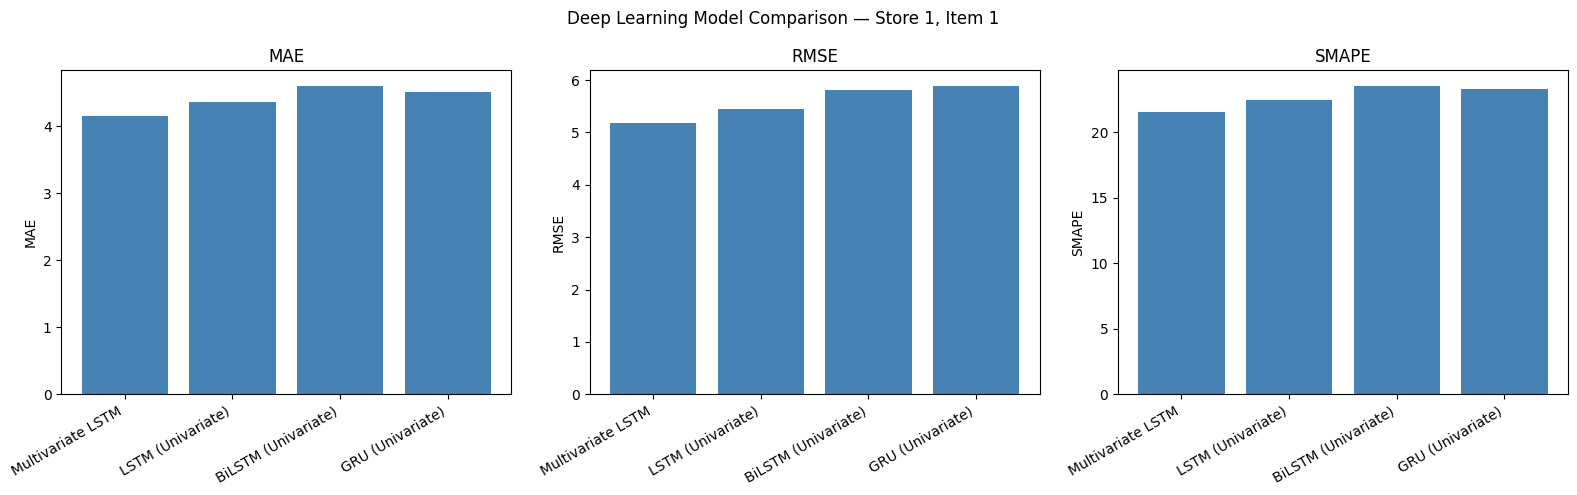

In [20]:
# Model Comparison Table
results_df = pd.DataFrame(results_dl).sort_values("RMSE")
 
print("\n" + "=" * 60)
print("DEEP LEARNING MODEL COMPARISON — Store 1, Item 1 Validation")
print("=" * 60)
print(results_df.to_string(index=False))
 
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, metric in enumerate(["MAE", "RMSE", "SMAPE"]):
    axes[i].bar(results_df["Model"], results_df[metric], color="steelblue")
    axes[i].set_title(metric)
    axes[i].set_xticklabels(results_df["Model"], rotation=30, ha="right")
    axes[i].set_ylabel(metric)
 
plt.suptitle("Deep Learning Model Comparison — Store 1, Item 1")
plt.tight_layout()
plt.show()

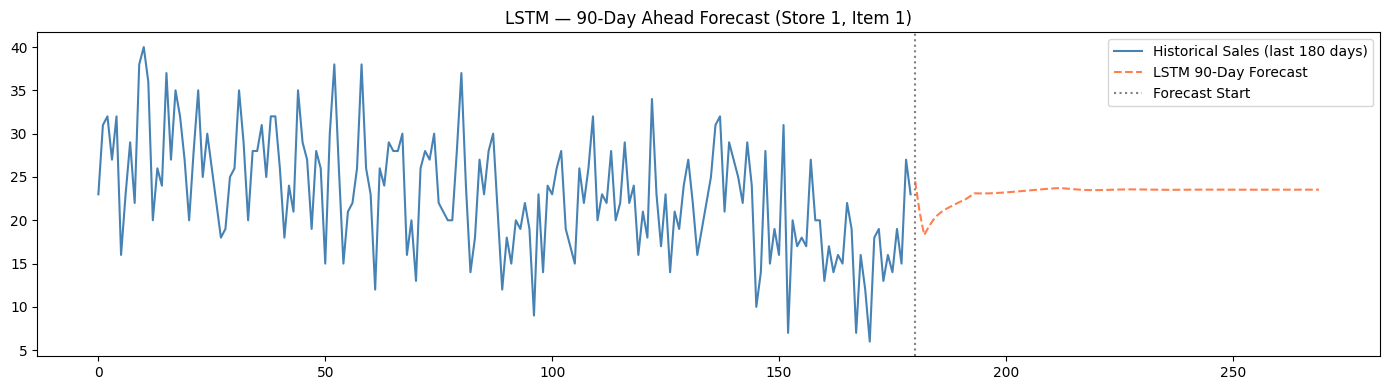

In [21]:
# Multi-Step Forecast with Best DL Model (recursive strategy)
def multi_step_forecast(model, last_sequence, n_steps, scaler):
    """
    Recursive multi-step forecast.
    Uses the model's own prediction as input for the next step.
    """
    preds = []
    current_seq = last_sequence.copy()   # shape (lookback, 1)
 
    for _ in range(n_steps):
        x = current_seq.reshape(1, LOOKBACK, 1)
        pred = model.predict(x, verbose=0)[0, 0]
        preds.append(pred)
        # Slide the window: drop oldest, append new prediction
        current_seq = np.roll(current_seq, -1)
        current_seq[-1] = pred
 
    # Inverse transform
    preds_orig = scaler.inverse_transform(np.array(preds).reshape(-1, 1)).flatten()
    preds_orig = np.clip(preds_orig, 0, None)
    return preds_orig
 
# Forecast next 90 days beyond training
last_seq = series_scaled[-LOOKBACK:].reshape(LOOKBACK, 1)
future_preds = multi_step_forecast(lstm_model, last_seq, n_steps=90, scaler=scaler)
 
plt.figure(figsize=(14, 4))
plt.plot(series[-180:], label="Historical Sales (last 180 days)", color="steelblue")
plt.plot(range(180, 180 + 90), future_preds, label="LSTM 90-Day Forecast",
         color="coral", linestyle="--")
plt.axvline(x=180, color="gray", linestyle=":", label="Forecast Start")
plt.title("LSTM — 90-Day Ahead Forecast (Store 1, Item 1)")
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
# Save Summary of All Saved Files
print("\n Notebook 3 Complete!")
print("\nAll saved files in saved_models/:")
for fname in sorted(os.listdir("saved_models")):
    path = os.path.join("saved_models", fname)
    size = os.path.getsize(path)
    print(f"  • {fname:45s} {size/1024:.1f} KB")
 
print("""

NEXT STEPS (coming in later notebooks):
 
  Notebook 4 → FastAPI Backend
    - Load LightGBM model (best ML model)
    - /predict endpoint: takes store, item, date → returns forecast
    - /batch_predict endpoint: CSV upload → returns forecasts
    - /health endpoint for monitoring
 
  Notebook 5 → Streamlit Dashboard
    - Store / Item selector
    - Date range picker
    - Actual vs Forecast chart
    - Model comparison tab
    - Batch prediction with CSV upload

""")
 


 Notebook 3 Complete!

All saved files in saved_models/:
  • adaboost.pkl                                  138.0 KB
  • arima_store1_item1.pkl                        7468.6 KB
  • bilstm_best.keras                             973.1 KB
  • bilstm_model.keras                            973.1 KB
  • gru_best.keras                                320.6 KB
  • gru_model.keras                               320.6 KB
  • linear_regression.pkl                         2.1 KB
  • lstm_best.keras                               403.2 KB
  • lstm_model.keras                              403.2 KB
  • lstm_scaler.pkl                               0.7 KB
  • mv_lstm_best.keras                            1678.0 KB
  • mv_lstm_meta.json                             0.2 KB
  • mv_lstm_model.keras                           1678.0 KB
  • mv_scaler_X.pkl                               1.2 KB
  • mv_scaler_y.pkl                               0.7 KB
  • prophet_store1_item1.pkl                      159.8 KB
  • r